# Check spinup

Plot some variables from the spinup simulation to see if they stabilise and reach equilibrium with the climate.

In [2]:
import xarray as xr  # NetCDF data handling
import matplotlib.pyplot as plt  # Plotting
import time  # Keeping track of runtime
import json  # For reading data dictionaries stored in json format
import datetime as dt  # for workaround with long simulations
from pathlib import Path
import pandas as pd
import numpy as np

In [3]:
spinup_file_path = "../../results/spinup.h0.concatenated_nc4.nc"
data = xr.open_mfdataset(spinup_file_path,
                         combine='by_coords',
                         decode_times=True
                         )

In [6]:
variables = ["FATES_VEGC_ABOVEGROUND", "TWS", "TOTSOMC", "TLAI"]

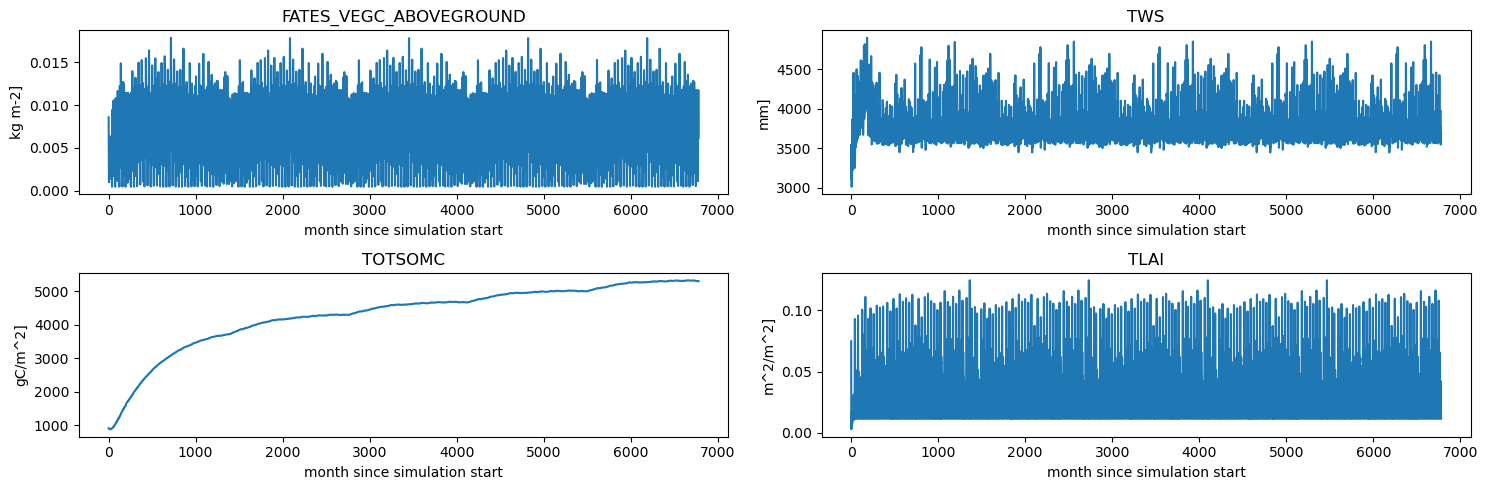

In [ ]:
# Instantiate figure with individual figures next to each other
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(15, 5)
)

# Delete empty axis object if number of variables is odd
if len(axes.flatten()) != len(variables):
    if len(axes.flatten()) == 2:
        fig.delaxes(axes[-1])
    else:
        fig.delaxes(axes[-1, -1])

# Plot all variables
for i, variable in enumerate(variables):
    ax = axes.flatten()[i]  # Get the appropriate axis object
    ax.plot(range(len(data["time"])), 
            data[variable]) 
    ax.set_title(variable)
    ax.set_xlabel("month since simulation start")
    ax.set_ylabel(f"{data[variable].units}]")

plt.tight_layout()  # Adjust spacing between subplots
plt.show()  # Show the plot
